 Importing the necessary librabries needed for the analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Loading the Dataset

In [ ]:
# Load dataset containing transaction records
df = pd.read_csv("/content/drive/MyDrive/Dataset.csv")

## Data Inspection and Cleaning

### Basic info: number of rows, columns, data types, non-null counts

In [ ]:
# Preview dataset
print("First 5 rows:")
df.head()

First 5 rows:


,Customer ID,Recipient,Amount,Tranx_Date,Tranx ID,Updated Time,Buying Price,Transaction Gateway,Seller Name,Vending Channel,Account Type,Location,product,Status
0,8304555449023,0807643XXXX,1650.0,2024-11-24 08:34:03,7222324112408349006592,2024-11-24 08:34:03,1615.0,GTW-3,CS1,Direct,postpaid,UK,data,Successful
1,8304555449023,0808341XXXX,1150.0,2024-11-24 13:37:55,7232124112413371719392,2024-11-24 13:37:56,1132.5,GTW-3,CS1,Direct,postpaid,UK,airtime,Successful
2,8304555449023,0703388XXXX,850.0,2024-11-24 09:02:44,7232424112409020587992,2024-11-24 09:02:45,843.0,GTW-2,CS2,Direct,postpaid,UK,airtime,Successful
3,8304555449023,0806770XXXX,750.0,2024-11-24 20:35:43,7222424112420356982192,2024-11-24 20:35:44,746.5,GTW-2,CS2,Direct,postpaid,UK,airtime,Successful
4,8304555449023,0802066XXXX,850.0,2024-11-24 08:31:21,7222124112408315785092,2024-11-24 08:31:22,843.0,GTW-3,CS1,Direct,postpaid,UK,airtime,Successful


In [ ]:
#To check the number of rows and columns in the dataset
df.shape

(648246, 14)

In [ ]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648246 entries, 0 to 648245
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Customer ID          648246 non-null  int64  
 1   Recipient            648246 non-null  object 
 2   Amount               648246 non-null  float64
 3   Tranx_Date           648246 non-null  object 
 4   Tranx ID             648246 non-null  object 
 5   Updated Time         643051 non-null  object 
 6   Buying Price         648246 non-null  float64
 7   Transaction Gateway  648246 non-null  object 
 8   Seller Name          648246 non-null  object 
 9   Vending Channel      648243 non-null  object 
 10  Account Type         648246 non-null  object 
 11  Location             648246 non-null  object 
 12  product              648246 non-null  object 
 13  Status               648246 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 69.

In [ ]:
# Rename product column for consistency with description
df.rename(columns={"product": "Product"}, inplace=True)

# Convert Customer ID to string (IDs are identifiers, not numeric)
df["Customer ID"] = df["Customer ID"].astype(str)

# Convert Tranx_Date and Updated Time to datetime objects for time calculations
df["Tranx_Date"] = pd.to_datetime(df["Tranx_Date"], errors='coerce')
df["Updated Time"] = pd.to_datetime(df["Updated Time"], errors='coerce')

In [ ]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648246 entries, 0 to 648245
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Customer ID          648246 non-null  object        
 1   Recipient            648246 non-null  object        
 2   Amount               648246 non-null  float64       
 3   Tranx_Date           648246 non-null  datetime64[ns]
 4   Tranx ID             648246 non-null  object        
 5   Updated Time         643051 non-null  datetime64[ns]
 6   Buying Price         648246 non-null  float64       
 7   Transaction Gateway  648246 non-null  object        
 8   Seller Name          648246 non-null  object        
 9   Vending Channel      648243 non-null  object        
 10  Account Type         648246 non-null  object        
 11  Location             648246 non-null  object        
 12  Product              648246 non-null  object        
 13 

Check for Missing Values and Handling

In [ ]:
# Checking for the number of missing values for each column
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 Customer ID               0
Recipient                 0
Amount                    0
Tranx_Date                0
Tranx ID                  0
Updated Time           5195
Buying Price              0
Transaction Gateway       0
Seller Name               0
Vending Channel           3
Account Type              0
Location                  0
Product                   0
Status                    0
dtype: int64


In [ ]:
# Fill minor missing categorical column
df["Vending Channel"] = df["Vending Channel"].fillna("Unknown")

In [ ]:
# Checking for missing values for each column after handling
print("\nMissing values per column:\n", df.isnull().sum())



Missing values per column:
 Customer ID               0
Recipient                 0
Amount                    0
Tranx_Date                0
Tranx ID                  0
Updated Time           5195
Buying Price              0
Transaction Gateway       0
Seller Name               0
Vending Channel           0
Account Type              0
Location                  0
Product                   0
Status                    0
dtype: int64


Out of 5,195 transactions missing Updated Time, 4,475 were successful.
For integrity of response time metrics, these rows were excluded only from calculations requiring timestamp data.
All other analyses (revenue, profit, success rate) include these transactions to prevent bias and preserve accurate business insights.”

### Duplicates and Standardization

In [ ]:
# Count duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicates: {duplicates}")

Duplicates: 0


The dataset do not contain duplicates

In [ ]:
# Standardize categorical fields

# Removes any leading or trailing spaces from the text in the "Status" column
df["Status"] = df["Status"].str.strip()

# Converts all text in the "Product" column to lowercase
df["Product"] = df["Product"].str.lower()

### **Feature Engineering**

In [ ]:
# Calculate profit per transaction
df["profit"] = df["Amount"] - df["Buying Price"]

# Create flag for successful transactions
df["is_success"] = df["Status"] == "Successful"

# Calculate response time (seconds) only for transactions with Updated Time
df["response_time"] = np.where(
    df["Updated Time"].notnull(),
    (df["Updated Time"] - df["Tranx_Date"]).dt.total_seconds(),
    np.nan
)

# Extract date for trend analysis
df["date"] = df["Tranx_Date"].dt.date
df["hour"] = df["Tranx_Date"].dt.hour


In [ ]:
df.head()

,Customer ID,Recipient,Amount,Tranx_Date,Tranx ID,Updated Time,Buying Price,Transaction Gateway,Seller Name,Vending Channel,Account Type,Location,Product,Status,profit,is_success,response_time,date,hour
0,8304555449023,0807643XXXX,1650.0,2024-11-24 08:34:03,7222324112408349006592,2024-11-24 08:34:03,1615.0,GTW-3,CS1,Direct,postpaid,UK,data,Successful,35.0,True,0.0,2024-11-24,8
1,8304555449023,0808341XXXX,1150.0,2024-11-24 13:37:55,7232124112413371719392,2024-11-24 13:37:56,1132.5,GTW-3,CS1,Direct,postpaid,UK,airtime,Successful,17.5,True,1.0,2024-11-24,13
2,8304555449023,0703388XXXX,850.0,2024-11-24 09:02:44,7232424112409020587992,2024-11-24 09:02:45,843.0,GTW-2,CS2,Direct,postpaid,UK,airtime,Successful,7.0,True,1.0,2024-11-24,9
3,8304555449023,0806770XXXX,750.0,2024-11-24 20:35:43,7222424112420356982192,2024-11-24 20:35:44,746.5,GTW-2,CS2,Direct,postpaid,UK,airtime,Successful,3.5,True,1.0,2024-11-24,20
4,8304555449023,0802066XXXX,850.0,2024-11-24 08:31:21,7222124112408315785092,2024-11-24 08:31:22,843.0,GTW-3,CS1,Direct,postpaid,UK,airtime,Successful,7.0,True,1.0,2024-11-24,8


### **DATA VALIDATION CHECK**

In [ ]:
print("\n--- DATA VALIDATION ---")

# Critical columns should have no missing values
critical_cols = ["Customer ID", "Amount", "Tranx_Date", "Product", "Status"]
for col in critical_cols:
    null_count = df[col].isnull().sum()
    print(f"{col} nulls: {null_count}")
    # Raise error if critical column has missing values
    assert null_count == 0, f"{col} has missing values!"

# Ensure Amount column is positive
invalid_amount = df[df["Amount"] <= 0].shape[0]
print(f"Invalid amount rows: {invalid_amount}")
assert invalid_amount == 0, "Amount contains zero or negative values!"

# Check that Status only contains valid values
valid_status = ["Successful", "Too much requests/System too Busy", "Wrong Product", "Other Errors", "Validation Error"]
invalid_status = df[~df["Status"].isin(valid_status)].shape[0]
print(f"Invalid status rows: {invalid_status}")
assert invalid_status == 0, "Unexpected status values found!"

# Confirm duplicates removed after cleaning
duplicates_check = df.duplicated().sum()
assert duplicates_check == 0, "Duplicates exist after cleaning!"

# Check for extreme losses (optional sanity check)
extreme_loss = df[df["profit"] < -10000].shape[0]
print(f"Extreme loss transactions: {extreme_loss}")

print("--- DATA VALIDATION COMPLETED ---\n")


--- DATA VALIDATION ---
Customer ID nulls: 0
Amount nulls: 0
Tranx_Date nulls: 0
Product nulls: 0
Status nulls: 0
Invalid amount rows: 0
Invalid status rows: 0
Extreme loss transactions: 0
--- DATA VALIDATION COMPLETED ---



**QUESTION 1: KPI CALCULATIONS**

In [ ]:
# 1. TOTAL REVENUE
# Definition:Total revenue represents the total value of all transactions processed.
# This is a key business metric used to measure overall sales performance.

total_revenue = df["Amount"].sum()
print(f"Total Revenue: ₦{total_revenue:,.2f}")

# Business Reason: Helps understand the scale of transactions and overall business volume.


# 2. TOTAL PROFIT
# Definition:Profit is calculated as the difference between selling price (Amount) and cost price (Buying Price) for each transaction.

total_profit = df["profit"].sum()
print(f"Total Profit: ₦{total_profit:,.2f}")

# Business Reason: Indicates how much the company is actually earning after costs. Revenue alone is not enough — profitability is key.


# 3. PROFIT MARGIN
# Definition: Profit margin shows how much profit is generated per unit of revenue.

profit_margin = total_profit / total_revenue
print(f"Profit Margin: {profit_margin:.2%}")

# Business Reason: Measures efficiency of pricing and cost control. Low margin may indicate high supplier cost or pricing inefficiencies.


# 4. SUCCESS RATE
# Definition: Percentage of transactions that were successful.

success_rate = df["is_success"].mean()
print(f"Success Rate: {success_rate:.2%}")

# Business Reason: Indicates system reliability and operational performance.
# Higher success rate = better customer experience and higher revenue retention.


# 5. FAILURE RATE
# Definition: Percentage of transactions that failed.

failure_rate = 1 - success_rate
print(f"Failure Rate: {failure_rate:.2%}")

# Business Reason: Represents lost revenue opportunities and system inefficiencies.
# Reducing failure rate directly improves business performance.


# 6. PRODUCT PERFORMANCE
# Definition: Evaluate how each product contributes to revenue, profit, and success rate.

product_perf = df.groupby("Product").agg({
    "Amount": "sum",        # Total revenue per product
    "profit": "sum",        # Total profit per product
    "is_success": "mean"    # Success rate per product
}).rename(columns={"is_success": "success_rate"})

print("\nProduct Performance:")
print(product_perf.sort_values("Amount", ascending=False))

# Business Reason:
# Helps identify:
# - Top revenue-generating products
# - Most profitable products
# - Products with high failure rates (operational issues)

# 7. TOTAL CUSTOMERS
# Total number of unique customers
total_customers = df["Customer ID"].nunique()

# Print to confirm
print(f"Total Customers: {total_customers}")
# Business Reason: Provides context on the size of the customer base.
# It also helps assess revenue concentration and dependency risk.


# 8. CUSTOMER CONTRIBUTION
# Definition: Measures how much each customer contributes to total revenue.

customer_revenue = df.groupby("Customer ID")["Amount"].sum().sort_values(ascending=False)

# Calculate top 5 contribution
top5_contribution = customer_revenue.head(5).sum() / customer_revenue.sum()

print(f"\nTop 5 Customers Contribution: {top5_contribution:.2%}")

# Display top customers
print("\nTop 10 Customers by Revenue:")
print(customer_revenue.head(10))

# Business Reason: Identifies key customers driving the business.
# Helps detect dependency risk if revenue is concentrated among few customers.


# ADDITIONAL KPI
# 9. Average transaction value

avg_transaction_value = df["Amount"].mean()
print(f"\nAverage Transaction Value: ₦{avg_transaction_value:,.2f}")

# Business Reason: Helps understand customer spending behavior.
# Useful for pricing strategy and segmentation.


# 10. FAILURE RATE BY PRODUCT
failure_by_product = df.groupby("Product")["is_success"].mean()
failure_by_product = 1 - failure_by_product

print("\nFailure Rate by Product:")
print(failure_by_product.sort_values(ascending=False))

# Business Reason: Identifies problematic products causing failures.
# Helps prioritize operational improvements.

Total Revenue: ₦825,427,453.37
Total Profit: ₦14,250,030.70
Profit Margin: 1.73%
Success Rate: 99.26%
Failure Rate: 0.74%

Product Performance:
                   Amount      profit  success_rate
Product                                            
airtime      5.934159e+08  9143862.46      0.995985
data         2.134928e+08  4879858.62      0.980848
electricity  1.223815e+07    80015.62      0.835804
cabletv      4.227350e+06    45656.50      0.970588
pin          1.938950e+06    98285.00      0.920904
startimes    1.143000e+05     2352.50      1.000000
Total Customers: 49

Top 5 Customers Contribution: 88.30%

Top 10 Customers by Revenue:
Customer ID
412476446244     4.361161e+08
8304555449023    1.124095e+08
9315518483834    8.746297e+07
431539048016     5.090020e+07
138455421218     4.199655e+07
315382484218     3.886244e+07
5365347429637    1.452343e+07
312645843913     1.151771e+07
1284897443076    9.136385e+06
3160254413516    8.881385e+06
Name: Amount, dtype: float64

Average Tr

**QUESTION 2: AVERAGE RESPONSE TIME PER PRODUCT**

In [ ]:
response_time_product = df.groupby("Product")["response_time"].mean()
# NaN values ignored automatically

print("\nAverage Response Time per Product (seconds):")
print(response_time_product.sort_values())

response_time_minutes = response_time_product / 60
print("\nAverage Response Time per Product (minutes):")
print(response_time_minutes.sort_values())


Average Response Time per Product (seconds):
Product
pin            0.030057
airtime        0.849070
data           1.275523
cabletv             NaN
electricity         NaN
startimes           NaN
Name: response_time, dtype: float64

Average Response Time per Product (minutes):
Product
pin            0.000501
airtime        0.014151
data           0.021259
cabletv             NaN
electricity         NaN
startimes           NaN
Name: response_time, dtype: float64


In [ ]:
# Definition:Response time = time difference between when a transaction was initiated (Tranx_Date) and when it was fulfilled (Updated Time)

# Note:
# Only transactions with valid Updated Time are considered
# Missing Updated Time values were excluded earlier to ensure accuracy


# Calculate average response time (Seconds)

# Group dataset by Product and calculate mean response time
response_time_product = df.groupby("Product")["response_time"].mean()

# Sort values in ascending order to identify fastest → slowest products
print("\nAverage Response Time per Product (in seconds):")
print(response_time_product.sort_values())


# Optional: Identify fastest and slowest product

# Fastest product (lowest response time)
fastest_product = response_time_product.idxmin()
fastest_time = response_time_product.min()

# Slowest product (highest response time)
slowest_product = response_time_product.idxmax()
slowest_time = response_time_product.max()

print(f"\nFastest Product: {fastest_product} ({fastest_time:.2f} seconds)")
print(f"Slowest Product: {slowest_product} ({slowest_time:.2f} seconds)")

# BUSINESS INTERPRETATION (INLINE COMMENT)


# Faster response time → better system efficiency and user experience
# Slower response time → potential delays due to system bottlenecks or external dependencies


Average Response Time per Product (in seconds):
Product
pin            0.030057
airtime        0.849070
data           1.275523
cabletv             NaN
electricity         NaN
startimes           NaN
Name: response_time, dtype: float64

Fastest Product: pin (0.03 seconds)
Slowest Product: data (1.28 seconds)


In [ ]:
# Identify products with no response time data
missing_response_products = response_time_product[response_time_product.isna()].index.tolist()

print("\nProducts with no response time data:")
print(missing_response_products)


Products with no response time data:
['cabletv', 'electricity', 'startimes']


**Advanced Analysis:Response Time vs Failure Rate**

In [ ]:
# Objective:
# To analyze the relationship between system latency (response time) and transaction reliability (failure rate) across products

# Failure rate per product = percentage of transactions that are not successful
failure_rate_product = 1 - df.groupby("Product")["is_success"].mean()


# Create a DataFrame for easy comparison
performance_analysis = pd.DataFrame({
    "avg_response_time_sec": response_time_product,
    "failure_rate": failure_rate_product
})


# Sort by failure rate (highest problem first)
performance_analysis = performance_analysis.sort_values(by="failure_rate", ascending=False)

print("\nResponse Time vs Failure Rate by Product:")
print(performance_analysis)

# Products with both high failure rate and high response time
# (potential system bottlenecks)
high_risk = performance_analysis[
    (performance_analysis["failure_rate"] > 0.05) &
    (performance_analysis["avg_response_time_sec"].notnull())
]

print("\nHigh Risk Products (High Failure + High Response Time):")
print(high_risk)



Response Time vs Failure Rate by Product:
             avg_response_time_sec  failure_rate
Product                                         
electricity                    NaN      0.164196
pin                       0.030057      0.079096
cabletv                        NaN      0.029412
data                      1.275523      0.019152
airtime                   0.849070      0.004015
startimes                      NaN      0.000000

High Risk Products (High Failure + High Response Time):
         avg_response_time_sec  failure_rate
Product                                     
pin                   0.030057      0.079096


**QUESTION 3: DAILY TREND FOR TOP 5 CUSTOMERS**


Top 5 Customers:
Index(['412476446244', '8304555449023', '9315518483834', '431539048016',
       '138455421218'],
      dtype='object', name='Customer ID')

Sample of Daily Trend Data:
         date    Customer ID      Amount
0  2024-11-24   138455421218   4712387.0
1  2024-11-24   412476446244  57117232.0
2  2024-11-24   431539048016   5495702.0
3  2024-11-24  8304555449023  14242763.0
4  2024-11-24  9315518483834  12279331.0


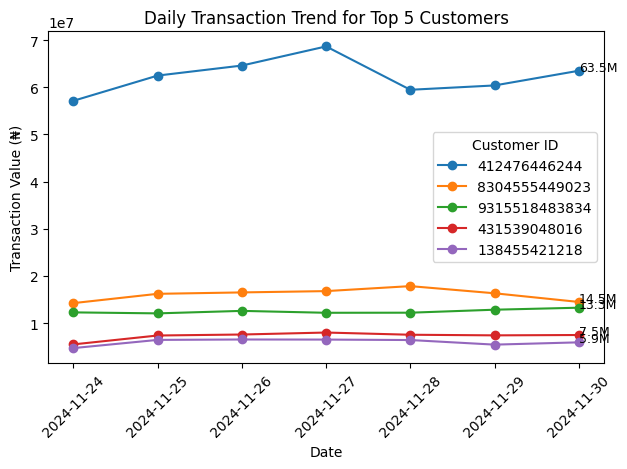


Customer Volatility (Std Dev of Daily Spend):
Customer ID
412476446244     3.776496e+06
8304555449023    1.275955e+06
431539048016     8.103883e+05
138455421218     6.945596e+05
9315518483834    4.341545e+05
Name: Amount, dtype: float64


<Figure size 640x480 with 0 Axes>

In [ ]:
%matplotlib inline
# Objective: To analyze transaction trends over time for the top 5 customers
# This helps understand customer behavior, consistency, and dependency risk

# Identify top 5 Customers

# Top customers are determined based on total transaction value (Amount)
top_customers = (
    df.groupby("Customer ID")["Amount"].sum().sort_values(ascending=False)
    .head(5).index
)

print("\nTop 5 Customers:")
print(top_customers)


# Keep only transactions belonging to the top 5 customers
df_top = df[df["Customer ID"].isin(top_customers)]

# Aggregate transaction value by date and customer. This gives daily spending trend per customer
daily_trend = (
    df_top.groupby(["date", "Customer ID"])["Amount"].sum().reset_index()
)

print("\nSample of Daily Trend Data:")
print(daily_trend.head())

# Plot line chart for each customer
# Each line represents a customer's daily transaction value

for cust in top_customers:
    customer_data = daily_trend[daily_trend["Customer ID"] == cust]

    plt.plot(
        customer_data["date"],
        customer_data["Amount"],
        marker='o',
        label=f"{cust}"
    )

    # Annotate ONLY last point (cleaner)
    last_x = customer_data["date"].iloc[-1]
    last_y = customer_data["Amount"].iloc[-1]

    plt.text(
        last_x, last_y,
        f"{last_y/1e6:.1f}M",
        fontsize=9,
        ha='left'
    )

# Formatting
plt.title("Daily Transaction Trend for Top 5 Customers")
plt.xlabel("Date")
plt.ylabel("Transaction Value (₦)")
plt.xticks(rotation=45)
plt.legend(title="Customer ID")
plt.tight_layout()

plt.show()
plt.savefig("top5_customers_trend_clean.png")
plt.clf()

# Addtional Analysis: Identify most consistent vs most volatile customer

# Calculate daily standard deviation per customer
volatility = (
    daily_trend.groupby("Customer ID")["Amount"]
    .std().sort_values(ascending=False)
)

print("\nCustomer Volatility (Std Dev of Daily Spend):")
print(volatility)

# Interpretation:
# Higher std = more fluctuation (less predictable)
# Lower std = more stable behavior

**QUESTION 4: LEAST PERFORMING CUSTOMERS PER PRODUCT**

In [ ]:
# Objective: Identify the bottom 10 customers per product based on performance

# Definition of "least performing": - Low total transaction value (Amount) & High failure rate
# This helps detect customers contributing little value and/or experiencing issues

# Aggregate customer performance per product

# Group by Product and Customer ID
performance = df.groupby(["Product", "Customer ID"]).agg({
    "Amount": "sum",        # Total transaction value per customer per product
    "is_success": "mean"    # Success rate (mean of True/False)
}).reset_index()

# Calculate failure rate

# Failure rate = 1 - success rate
performance["failure_rate"] = 1 - performance["is_success"]


# Define Performance Score

# Create a combined metric to rank customers: Lower Amount + Higher Failure Rate = Worse performance

# Normalize Amount (to bring to same scale)
performance["normalized_amount"] = performance["Amount"] / performance["Amount"].max()

# Performance score (lower is worse)
performance["performance_score"] = (
    performance["normalized_amount"] * performance["is_success"]
)

# Identify least Perfoming Customers

# Sort:
# - Lowest Amount first
# - Highest failure rate first

least_performing = (
    performance
    .sort_values(
        by=["Product", "Amount", "failure_rate"],
        ascending=[True, True, False]
    )
    .groupby("Product")
    .head(10)   # Bottom 10 per product
)

print("\nLeast Performing Customers per Product:")
print(least_performing)

# OPTIONAL — FOCUS ON CRITICAL CASES

# Customers with high failure rate (> 10%)
high_failure_customers = performance[performance["failure_rate"] > 0.1]

print("\nCustomers with High Failure Rate (>10%):")
print(high_failure_customers.sort_values(by="failure_rate", ascending=False))


Least Performing Customers per Product:
         Product     Customer ID     Amount  is_success  failure_rate  \
27       airtime  53733683488385      750.0    1.000000      0.000000   
32       airtime    638422451183      950.0    1.000000      0.000000   
7        airtime   2326019439095     1150.0    1.000000      0.000000   
19       airtime   3733625420153     1650.0    1.000000      0.000000   
15       airtime  33733665459469     1900.0    1.000000      0.000000   
16       airtime  33733675434772     2750.0    1.000000      0.000000   
9        airtime   3122784473224     2890.0    1.000000      0.000000   
41       airtime  93733693420416     3150.0    1.000000      0.000000   
5        airtime   1733499421416     4150.0    1.000000      0.000000   
22       airtime    416404425437     4650.0    1.000000      0.000000   
51       cabletv    917000447287     1400.0    0.500000      0.500000   
43       cabletv   2711999437214     3950.0    1.000000      0.000000   
47       c

In [ ]:
least_performing.to_csv("least_performing_customers.csv", index=False)

In [ ]:
# files.download("least_performing_customers.csv")

**QUESTION 5: CUSTOMER SUMMARY TABLE**

In [ ]:
# Objective: Build a comprehensive customer-level summary table
# capturing performance, revenue contribution, and failure behavior

# Total Transaction Value (for % contribution)
total_value = df["Amount"].sum()

# Product Failure Rate
def product_failure_rate(product_name):
    subset = df[df["Product"] == product_name]
    rate = subset.groupby("Customer ID")["is_success"].mean()
    return 1 - rate

customer_summary = (
    df.groupby("Customer ID").agg(
        successful_facevalue=("Amount", lambda x: x[df.loc[x.index, "is_success"]].sum()),
        failed_facevalue=("Amount", lambda x: x[~df.loc[x.index, "is_success"]].sum()),
        estimated_profit=("profit", lambda x: x[df.loc[x.index, "is_success"]].sum()),
        total_value=("Amount", "sum"),
        successful_count=("is_success", "sum"),
        total_count=("is_success", "count")
    )
    .reset_index()
)

# Value contribution
customer_summary["value_contribution_pct"] = (
    customer_summary["total_value"] / total_value * 100
)

# Failure rate
customer_summary["failure_rate"] = (
    1 - (customer_summary["successful_count"] / customer_summary["total_count"])
)

# Product-level failure rates
customer_summary["airtime_failure_rate"] = customer_summary["Customer ID"].map(product_failure_rate("airtime"))
customer_summary["data_failure_rate"] = customer_summary["Customer ID"].map(product_failure_rate("data"))
customer_summary["cabletv_failure_rate"] = customer_summary["Customer ID"].map(product_failure_rate("cabletv"))
customer_summary["electricity_failure_rate"] = customer_summary["Customer ID"].map(product_failure_rate("electricity"))

# Fill missing values
customer_summary = customer_summary.fillna(0)

# Sort
customer_summary = customer_summary.sort_values(by="total_value", ascending=False)

# Output
print(customer_summary.head(10))
customer_summary.to_csv("customer_summary.csv", index=False)

      Customer ID  successful_facevalue  failed_facevalue  estimated_profit  \
21   412476446244          4.340243e+08        2091840.35        6706152.55   
39  8304555449023          1.108308e+08        1578697.00        1881583.31   
45  9315518483834          8.624745e+07        1215519.00        2353632.65   
23   431539048016          4.998328e+07         916919.00         664967.33   
2    138455421218          4.109796e+07         898585.00         811985.00   
11   315382484218          3.829516e+07         567280.00         658504.91   
28  5365347429637          1.411840e+07         405026.00         254857.21   
10   312645843913          1.122456e+07         293150.00         213710.34   
0   1284897443076          9.066669e+06          69716.00         191794.67   
13  3160254413516          8.724796e+06         156589.00         111081.71   

     total_value  successful_count  total_count  value_contribution_pct  \
21  4.361161e+08            371574       372963        

In [ ]:
# files.download("customer_summary.csv")